# Data Collection
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

In [29]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier




In [30]:
# read the data

data = pd.read_csv(r'C:\disk1\AI_CS_IEEE-ZSB-26\Task_7\Travel.csv')


## Data Cleaning

In [31]:
data.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

In [33]:
data.shape

(4888, 20)

In [34]:
pd.DataFrame(data.isnull().sum())

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


In [35]:
pd.DataFrame(data.isnull().sum()/len(data)*100,columns=['Missing Values Percentage'])

,Missing Values Percentage
CustomerID,0.000000
ProdTaken,0.000000
Age,4.623568
TypeofContact,0.511457
CityTier,0.000000
DurationOfPitch,5.135025
Occupation,0.000000
Gender,0.000000
NumberOfPersonVisiting,0.000000
NumberOfFollowups,0.920622


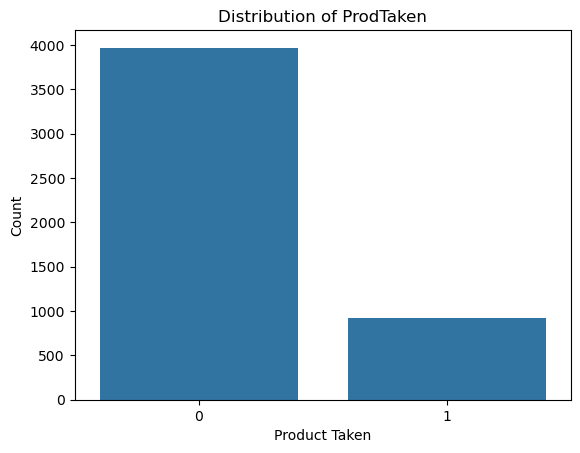

In [36]:
sns.countplot(x='ProdTaken', data=data)
plt.title('Distribution of ProdTaken')
plt.xlabel('Product Taken')
plt.ylabel('Count') 
plt.show()

In [37]:
data.columns = data.columns.str.strip()

cols_fill = [
    'Age', 'TypeofContact', 'DurationOfPitch', 'NumberOfFollowups',
    'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips',
    'Passport', 'PitchSatisfactionScore', 'OwnCar',
    'NumberOfChildrenVisiting', 'MonthlyIncome'
]

for col in cols_fill:
    if pd.api.types.is_numeric_dtype(data[col]):
        data[col] = data[col].fillna(data[col].median())
    else:
        data[col] = data[col].fillna(data[col].mode()[0])
pd.DataFrame(data.isnull().sum()/len(data)*100,columns=['Missing Values Percentage'])

,Missing Values Percentage
CustomerID,0.0
ProdTaken,0.0
Age,0.0
TypeofContact,0.0
CityTier,0.0
DurationOfPitch,0.0
Occupation,0.0
Gender,0.0
NumberOfPersonVisiting,0.0
NumberOfFollowups,0.0


In [38]:
numerical_columns = data.select_dtypes(include=[np.number]).columns
Q1 = data[numerical_columns].quantile(0.25)
Q3 = data[numerical_columns].quantile(0.75)
IQR = Q3 - Q1
outliers = ((data[numerical_columns] < (Q1 - 1.5 * IQR)) | (data[numerical_columns] > (Q3 + 1.5 * IQR))).sum()
print(outliers)

CustomerID                    0
ProdTaken                   920
Age                           0
CityTier                      0
DurationOfPitch             112
NumberOfPersonVisiting        3
NumberOfFollowups           312
PreferredPropertyStar         0
NumberOfTrips               109
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting      0
MonthlyIncome               375
dtype: int64


In [39]:
def handle_outliers_iqr(data, method="cap", target_col=None):

    df = data.copy()
    cleaned_cols = []

    num_cols = data.select_dtypes(include='number').columns

    for col in num_cols:

 
        if col == target_col:
            continue

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if method == "cap":
            data[col] = data[col].clip(lower, upper)

  
        elif method == "drop":
            if col != "ProdTaken":
                data = data[(data[col] >= lower) & (data[col] <= upper)]
        

        cleaned_cols.append(col)


    return data
data_clean = handle_outliers_iqr(data, method="drop")


outliers = ((data_clean[numerical_columns] < (Q1 - 1.5 * IQR)) | (data_clean[numerical_columns] > (Q3 + 1.5 * IQR))).sum()
print(outliers)

CustomerID                    0
ProdTaken                   766
Age                           0
CityTier                      0
DurationOfPitch               0
NumberOfPersonVisiting        0
NumberOfFollowups             0
PreferredPropertyStar         0
NumberOfTrips                 0
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting      0
MonthlyIncome                 9
dtype: int64


In [40]:

numeric_cols = data_clean.select_dtypes(include=[np.number]).columns
skewness = data_clean[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numeric features:")
print(skewness)


Skewness of numeric features:
ProdTaken                   1.580001
DurationOfPitch             0.927843
Passport                    0.898791
PreferredPropertyStar       0.886952
NumberOfTrips               0.818081
CityTier                    0.687971
MonthlyIncome               0.681462
Age                         0.518262
NumberOfChildrenVisiting    0.292686
CustomerID                  0.058283
NumberOfPersonVisiting      0.040490
NumberOfFollowups          -0.082532
PitchSatisfactionScore     -0.130032
OwnCar                     -0.460122
dtype: float64


## Feature Engineering & Encoding

In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
label_encoder = LabelEncoder()
categorical_cols = data_clean.select_dtypes(include=['object']).columns
for col in categorical_cols:
    data_clean[col] = label_encoder.fit_transform(data_clean[col])
for i in data_clean.columns:
    data_clean[i] = MinMaxScaler().fit_transform(data_clean[[i]])
data_clean.head()



,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0.000000,1.0,0.534884,1.0,1.0,0.034483,0.666667,0.5,0.666667,0.333333,0.25,0.0,0.666667,0.000000,1.0,0.25,1.0,0.000000,0.50,0.294650
1,0.000205,0.0,0.720930,0.0,0.0,0.310345,0.666667,1.0,0.666667,0.666667,0.25,0.5,0.000000,0.166667,0.0,0.50,1.0,0.666667,0.50,0.243630
2,0.000409,1.0,0.441860,1.0,0.0,0.103448,0.000000,1.0,0.666667,0.666667,0.00,0.0,0.666667,1.000000,1.0,0.50,0.0,0.000000,0.25,0.063908
3,0.000614,0.0,0.348837,0.0,0.0,0.137931,0.666667,0.5,0.333333,0.333333,0.00,0.0,0.000000,0.166667,1.0,1.00,1.0,0.333333,0.25,0.112326
4,0.000818,0.0,0.418605,1.0,0.0,0.103448,1.000000,1.0,0.333333,0.333333,0.00,0.5,0.000000,0.000000,0.0,1.00,1.0,0.000000,0.25,0.145374


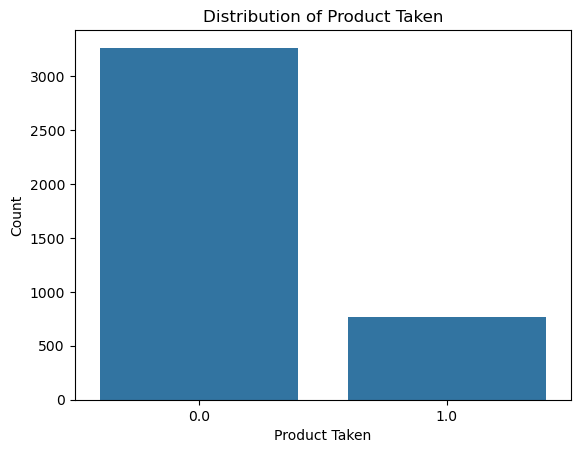

In [42]:
sns.countplot(x='ProdTaken', data=data_clean)
plt.title('Distribution of Product Taken')
plt.xlabel('Product Taken')
plt.ylabel('Count')
plt.show()

In [43]:
from imblearn.over_sampling import SMOTE
X = data_clean.drop('ProdTaken', axis=1)
y = data_clean['ProdTaken']
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
data_resampled = pd.concat([X_resampled, y_resampled], axis=1)
print("Distribution of Product Taken after SMOTE:")
print(data_resampled['ProdTaken'].value_counts())
print("Distribution of Product Taken Before SMOTE:")
print(data_clean['ProdTaken'].value_counts())

Distribution of Product Taken after SMOTE:
ProdTaken
1.0    3263
0.0    3263
Name: count, dtype: int64
Distribution of Product Taken Before SMOTE:
ProdTaken
0.0    3263
1.0     766
Name: count, dtype: int64


#### Build a classification model using support vector machine. Use standalone model as well as Bagging model and check if you see any difference in the performance.

In [44]:
X = data_resampled.drop('ProdTaken', axis=1)
y = data_resampled['ProdTaken']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [45]:
model = SVC(kernel='rbf', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [46]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89       680
         1.0       0.86      0.90      0.88       626

    accuracy                           0.88      1306
   macro avg       0.88      0.89      0.88      1306
weighted avg       0.89      0.88      0.88      1306

Confusion Matrix:
[[589  91]
 [ 60 566]]
Accuracy Score: 0.8843797856049005


In [47]:
print("SVC Model test score:", accuracy_score(y_test, y_pred))
print("SVC Model train score:", accuracy_score(y_train, model.predict(X_train)))

SVC Model test score: 0.8843797856049005
SVC Model train score: 0.8909961685823755


#### Now use decision tree classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [48]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train, y_train)
y_pred_dt = model_dt.predict(X_test)
print("Classification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix for Decision Tree:")
print(confusion_matrix(y_test, y_pred_dt))
print("Accuracy Score for Decision Tree:", accuracy_score(y_test, y_pred_dt))


Classification Report for Decision Tree:
              precision    recall  f1-score   support

         0.0       0.94      0.90      0.92       680
         1.0       0.90      0.94      0.92       626

    accuracy                           0.92      1306
   macro avg       0.92      0.92      0.92      1306
weighted avg       0.92      0.92      0.92      1306

Confusion Matrix for Decision Tree:
[[614  66]
 [ 38 588]]
Accuracy Score for Decision Tree: 0.9203675344563553


In [49]:
print("Decision Tree Model test score:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Model train score:", accuracy_score(y_train, model_dt.predict(X_train)))

Decision Tree Model test score: 0.9203675344563553
Decision Tree Model train score: 1.0


#### then use random forest classifier. Use standalone model as well as Bagging and check if you notice any difference in performance

In [50]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print("Classification Report for Random Forest:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix for Random Forest:")
print(confusion_matrix(y_test, y_pred_rf))
print("Accuracy Score for Random Forest:", accuracy_score(y_test, y_pred_rf))


Classification Report for Random Forest:
              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       680
         1.0       0.97      0.96      0.97       626

    accuracy                           0.97      1306
   macro avg       0.97      0.97      0.97      1306
weighted avg       0.97      0.97      0.97      1306

Confusion Matrix for Random Forest:
[[663  17]
 [ 26 600]]
Accuracy Score for Random Forest: 0.9670750382848392


In [51]:
print("Random Forest Model test score:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Model train score:", accuracy_score(y_train, model_rf.predict(X_train)))

Random Forest Model test score: 0.9670750382848392
Random Forest Model train score: 1.0


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print("Classification Report for KNN:")
print(classification_report(y_test, y_pred_knn))
print("Confusion Matrix for KNN:")
print(confusion_matrix(y_test, y_pred_knn))
print("Accuracy Score for KNN:", accuracy_score(y_test, y_pred_knn))


Classification Report for KNN:
              precision    recall  f1-score   support

         0.0       0.99      0.78      0.87       680
         1.0       0.81      0.99      0.89       626

    accuracy                           0.88      1306
   macro avg       0.90      0.89      0.88      1306
weighted avg       0.90      0.88      0.88      1306

Confusion Matrix for KNN:
[[533 147]
 [  6 620]]
Accuracy Score for KNN: 0.8828483920367535


In [53]:
print("KNN Model test score:", accuracy_score(y_test, y_pred_knn))
print("KNN Model train score:", accuracy_score(y_train, model_knn.predict(X_train)))


KNN Model test score: 0.8828483920367535
KNN Model train score: 0.9258620689655173


In [54]:
# logestic regression
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))
print("Accuracy Score for Logistic Regression:", accuracy_score(y_test, y_pred_lr))


Classification Report for Logistic Regression:
              precision    recall  f1-score   support

         0.0       0.76      0.73      0.74       680
         1.0       0.71      0.74      0.73       626

    accuracy                           0.74      1306
   macro avg       0.74      0.74      0.73      1306
weighted avg       0.74      0.74      0.74      1306

Confusion Matrix for Logistic Regression:
[[494 186]
 [160 466]]
Accuracy Score for Logistic Regression: 0.7350689127105666


In [55]:
print("Logistic Regression Model test score:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Model train score:", accuracy_score(y_train, model_lr.predict(X_train)))

Logistic Regression Model test score: 0.7350689127105666
Logistic Regression Model train score: 0.7229885057471265


#### Comparing performance of them to figure out where it makes most sense to use bagging and why. What conditions bagging works the best.

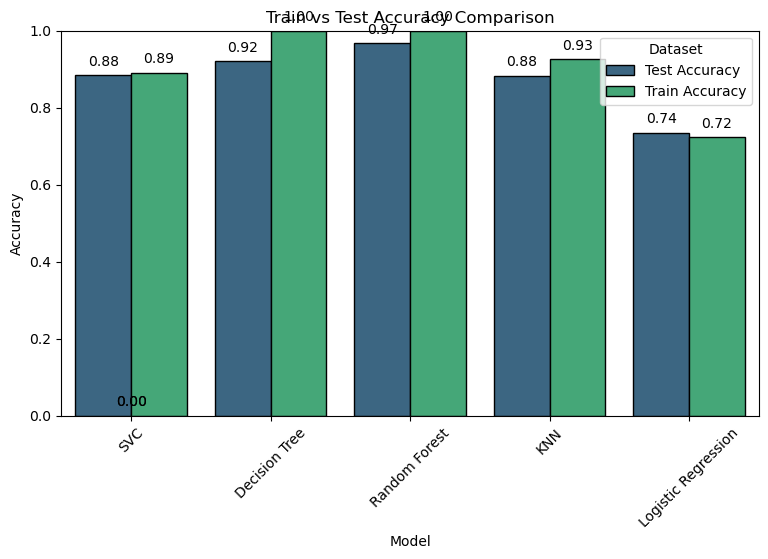

In [ ]:

df = pd.DataFrame({
    "Model": list(accuracy_scores_test.keys()),
    "Test Accuracy": list(accuracy_scores_test.values()),
    "Train Accuracy": list(accuracy_scores_train.values())
})
df_melt = df.melt(id_vars="Model", var_name="Dataset", value_name="Accuracy")

plt.figure(figsize=(9,5))
ax = sns.barplot(data=df_melt, x="Model", y="Accuracy", hue="Dataset",
                 palette="viridis", edgecolor="black")

plt.xticks(rotation=45)
plt.title("Train vs Test Accuracy Comparison")
plt.ylim(0,1)


for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10,
                xytext=(0,5),
                textcoords='offset points')

plt.show()